In [ ]:
# ============================================================
# AI Marketing Intelligence System for Amazon Product Reviews
# Final Exam Notebook Code
# Dataset: Reviews(2).csv
# ============================================================

# ------------------------------------------------------------
# INSTALL REQUIRED LIBRARIES
# ------------------------------------------------------------

!pip install textblob wordcloud -q

# ------------------------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from IPython.display import display, Markdown

import warnings
warnings.filterwarnings("ignore")

sns.set(rc={"figure.figsize": (10, 6)})

display(Markdown("# AI Marketing Intelligence System for Amazon Product Reviews"))

display(Markdown("""
This notebook builds an AI-based marketing decision system using Amazon product review data.
The system cleans customer review data, analyzes customer behavior, segments users, predicts review sentiment,
recommends products, and performs sentiment analysis for marketing decisions.
"""))

# AI Marketing Intelligence System for Amazon Product Reviews


This notebook builds an AI-based marketing decision system using Amazon product review data.
The system cleans customer review data, analyzes customer behavior, segments users, predicts review sentiment,
recommends products, and performs sentiment analysis for marketing decisions.


In [ ]:
# ============================================================
# DATASET LOADING
# ============================================================

display(Markdown("## Dataset Loading"))

file_path = "Reviews.csv"

df = pd.read_csv(file_path, nrows=100000)

print("Dataset loaded successfully")
print("Rows and columns:", df.shape)

display(df.head())
df.info()

## Dataset Loading

Dataset loaded successfully
Rows and columns: (100000, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      100000 non-null  int64 
 1   ProductId               100000 non-null  object
 2   UserId                  100000 non-null  object
 3   ProfileName             99994 non-null   object
 4   HelpfulnessNumerator    100000 non-null  int64 
 5   HelpfulnessDenominator  100000 non-null  int64 
 6   Score                   100000 non-null  int64 
 7   Time                    100000 non-null  int64 
 8   Summary                 99998 non-null   object
 9   Text                    100000 non-null  object
dtypes: int64(5), object(5)
memory usage: 7.6+ MB


In [ ]:
# ============================================================
# TASK 1: DATA CLEANING & CUSTOMER DATA PREPARATION
# ============================================================

display(Markdown("## Task 1: Data Cleaning & Customer Data Preparation"))

display(Markdown("""
In this task, we clean the dataset by removing duplicates, handling missing values,
fixing data types, and creating new marketing-related features.
Clean data is important because it helps us build better AI models and more accurate Power BI dashboards.
"""))

# Check missing values
print("Missing values before cleaning:")
display(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
df["ProfileName"] = df["ProfileName"].fillna("Unknown User")
df["Summary"] = df["Summary"].fillna("No Summary")
df["Text"] = df["Text"].fillna("No Review Text")

# Convert Unix time to normal date
df["ReviewDate"] = pd.to_datetime(df["Time"], unit="s")

# Create new date columns
df["ReviewYear"] = df["ReviewDate"].dt.year
df["ReviewMonth"] = df["ReviewDate"].dt.month
df["ReviewDay"] = df["ReviewDate"].dt.day

# Review length
df["ReviewLength"] = df["Text"].astype(str).apply(len)

# Helpfulness ratio
df["HelpfulnessRatio"] = df["HelpfulnessNumerator"] / df["HelpfulnessDenominator"].replace(0, np.nan)
df["HelpfulnessRatio"] = df["HelpfulnessRatio"].fillna(0)

# Sentiment label based on Score
def score_to_sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df["ScoreSentiment"] = df["Score"].apply(score_to_sentiment)

# Positive target for predictive model
df["PositiveReview"] = np.where(df["Score"] >= 4, 1, 0)

print("Missing values after cleaning:")
display(df.isnull().sum())

print("Cleaned dataset:")
display(df.head())

display(Markdown("""
### Interpretation

The dataset was cleaned and prepared for analysis.
We removed duplicate records, handled missing text values, converted the time column into a real date,
and created new useful columns such as ReviewLength, HelpfulnessRatio, ReviewYear, ReviewMonth, and ScoreSentiment.
These features will help us analyze customer behavior and build AI models.
"""))

## Task 1: Data Cleaning & Customer Data Preparation


In this task, we clean the dataset by removing duplicates, handling missing values,
fixing data types, and creating new marketing-related features.
Clean data is important because it helps us build better AI models and more accurate Power BI dashboards.


Missing values before cleaning:


,0
Id,0
ProductId,0
UserId,0
ProfileName,6
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,2
Text,0


Missing values after cleaning:


,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


Cleaned dataset:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,ReviewDate,ReviewYear,ReviewMonth,ReviewDay,ReviewLength,HelpfulnessRatio,ScoreSentiment,PositiveReview
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,2011-04-27,2011,4,27,263,1.0,Positive,1
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,2012-09-07,2012,9,7,190,0.0,Negative,0
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,2008-08-18,2008,8,18,509,1.0,Positive,1
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,2011-06-13,2011,6,13,219,1.0,Negative,0
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,2012-10-21,2012,10,21,140,0.0,Positive,1



### Interpretation

The dataset was cleaned and prepared for analysis.  
We removed duplicate records, handled missing text values, converted the time column into a real date,
and created new useful columns such as ReviewLength, HelpfulnessRatio, ReviewYear, ReviewMonth, and ScoreSentiment.
These features will help us analyze customer behavior and build AI models.


## Task 2: Exploratory Data Analysis & Customer Insights


In this task, we explore customer review behavior.
We analyze rating distribution, sentiment distribution, review trends over time,
product popularity, customer activity, correlations, and outliers.
This helps the marketing team understand customer behavior and product performance.


Basic statistics:


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,ReviewDate,ReviewYear,ReviewMonth,ReviewDay,ReviewLength,HelpfulnessRatio,PositiveReview
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,1.639790,2.119960,4.152630,1.296225e+09,2011-01-28 14:32:30.624000,2010.585710,6.413610,15.745260,442.108920,0.401524,0.770550
min,1.000000,0.000000,0.000000,1.000000,9.486720e+08,2000-01-24 00:00:00,2000.000000,1.000000,1.000000,33.000000,0.000000,0.000000
25%,25000.750000,0.000000,0.000000,4.000000,1.270512e+09,2010-04-06 00:00:00,2010.000000,3.000000,8.000000,183.000000,0.000000,1.000000
50%,50000.500000,0.000000,1.000000,5.000000,1.311725e+09,2011-07-27 00:00:00,2011.000000,7.000000,16.000000,308.000000,0.000000,1.000000
75%,75000.250000,2.000000,2.000000,5.000000,1.332720e+09,2012-03-26 00:00:00,2012.000000,9.000000,23.000000,537.000000,1.000000,1.000000
max,100000.000000,559.000000,562.000000,5.000000,1.351210e+09,2012-10-26 00:00:00,2012.000000,12.000000,31.000000,16952.000000,3.000000,1.000000
std,28867.657797,6.368915,6.991061,1.320141,4.782053e+07,NaN,1.522017,3.370197,8.788373,444.804185,0.460153,0.420481


Dataset columns:


Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'ReviewDate', 'ReviewYear', 'ReviewMonth', 'ReviewDay', 'ReviewLength',
       'HelpfulnessRatio', 'ScoreSentiment', 'PositiveReview'],
      dtype='object')

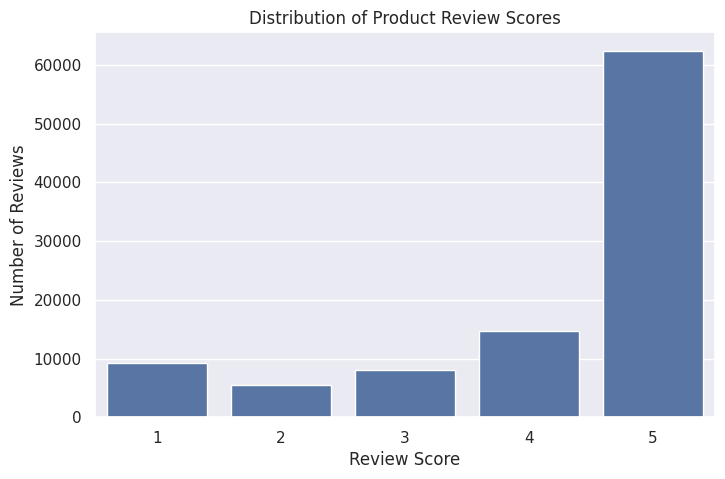


### Interpretation

This chart shows how customers rate products.
If scores 4 and 5 are the most common, it means most customers are satisfied.
For marketing, positive reviews can be used as social proof in advertisements and product pages.


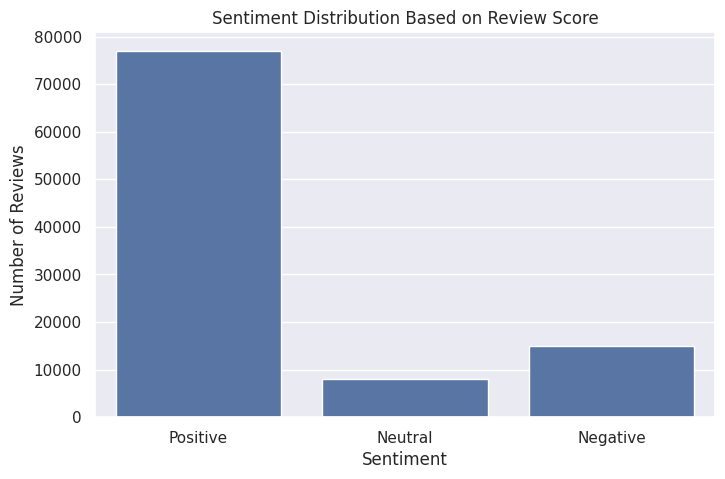


### Interpretation

This chart groups reviews into positive, neutral, and negative categories.
It helps the company quickly understand the general customer mood.


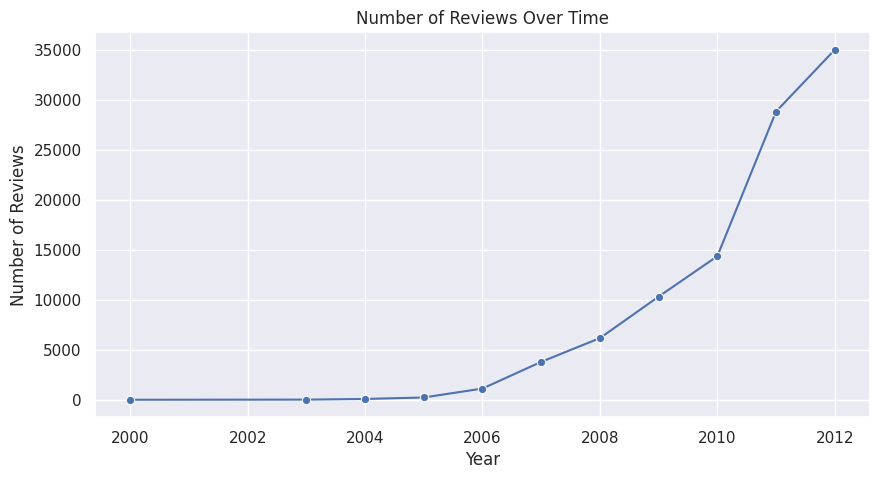


### Interpretation

This line chart shows how customer review activity changed over time.
An increase in reviews can mean higher product popularity, stronger customer engagement, or platform growth.


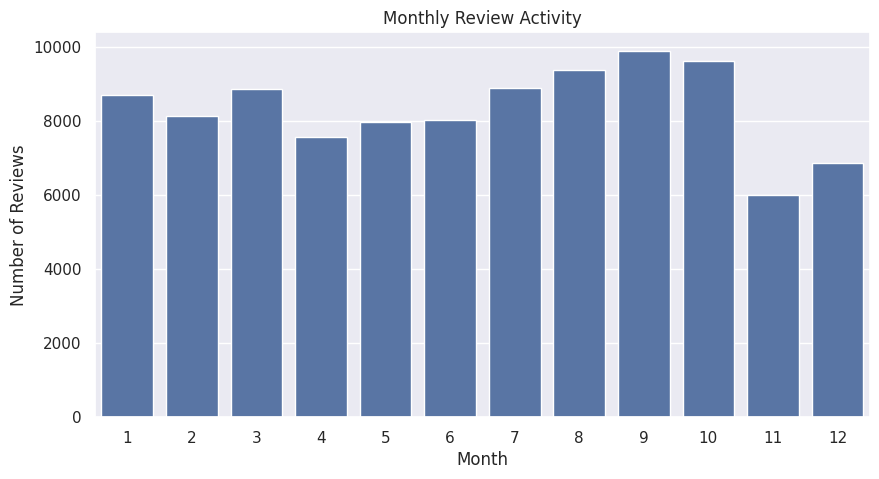


### Interpretation

This chart shows seasonal patterns in review activity.
If some months have more reviews, marketers can plan stronger campaigns during those periods.


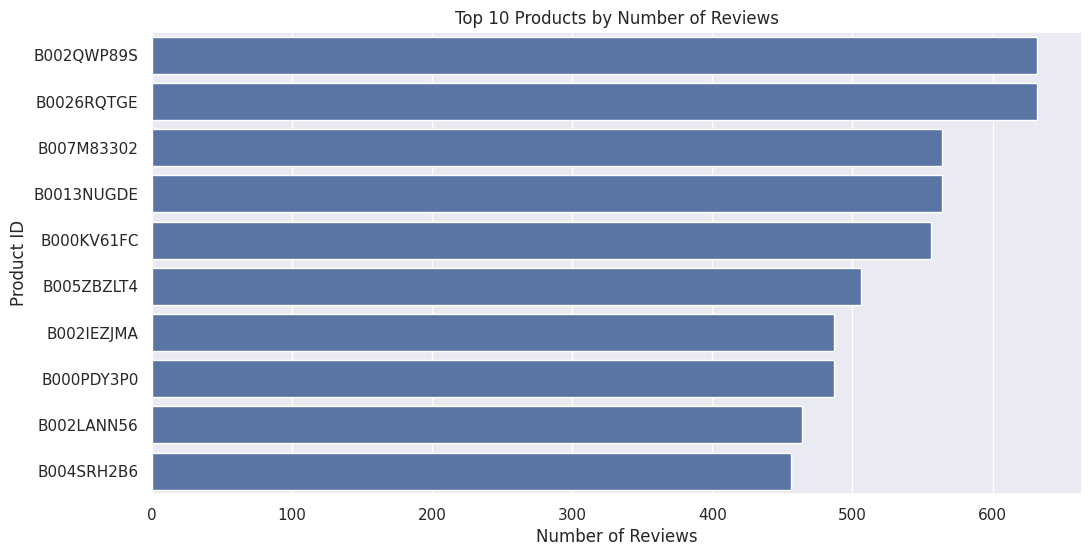


### Interpretation

These are the most reviewed products in the dataset.
Products with many reviews can be considered highly visible or popular.
Marketing teams can focus on these products for promotions or product improvement.


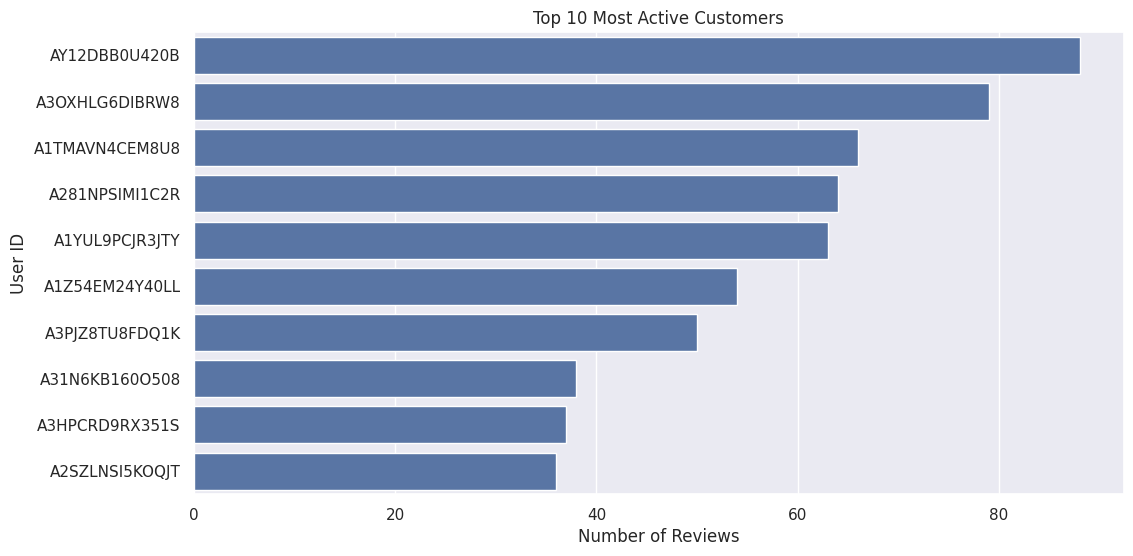


### Interpretation

This chart shows the most active customers based on review count.
These customers can be useful for loyalty programs, beta testing, and customer advocacy campaigns.


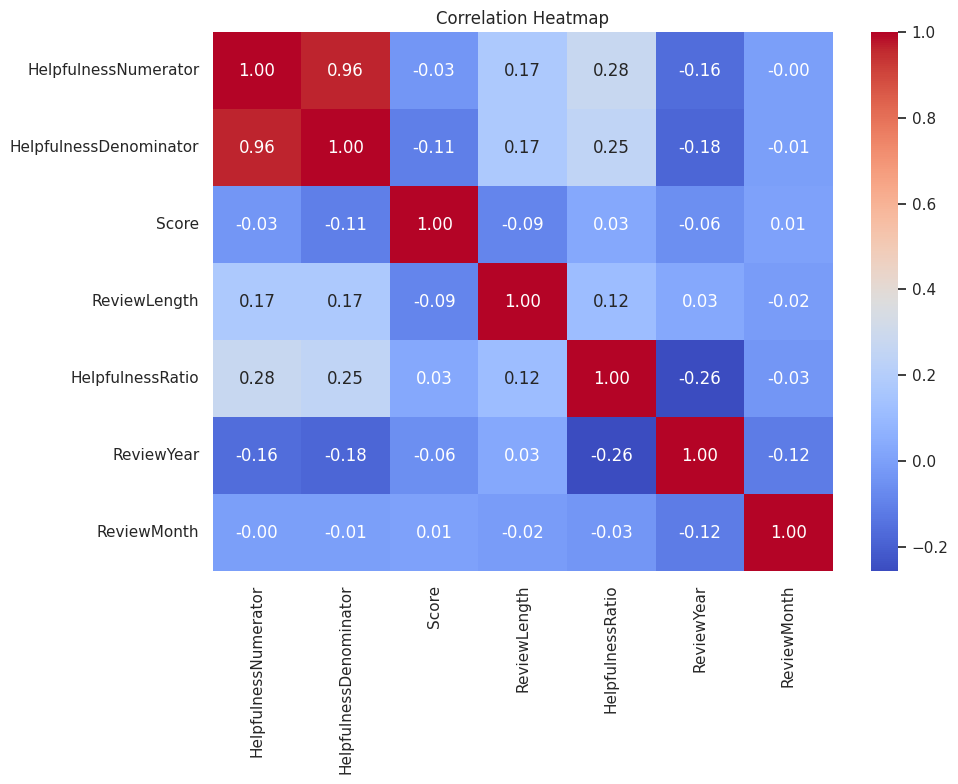


### Interpretation

The correlation heatmap shows relationships between numeric variables.
It helps us see which variables move together.
For example, helpfulness numerator and denominator are usually connected because both measure review usefulness.


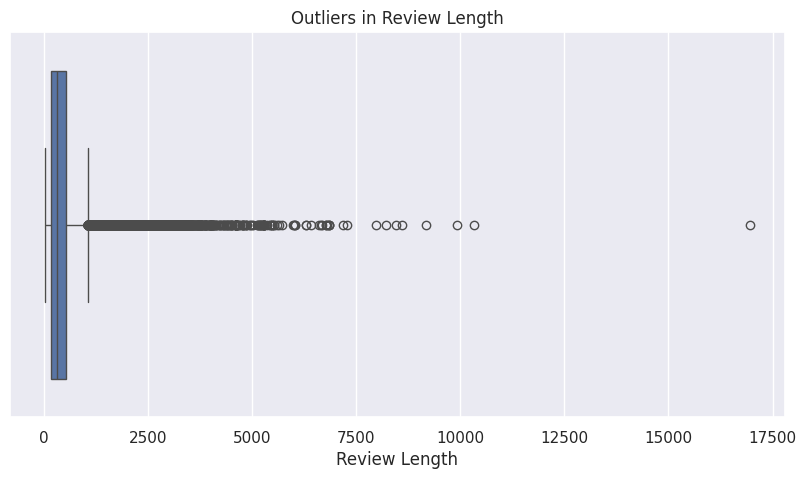


### Interpretation

The boxplot shows that some reviews are much longer than others.
Long reviews can be important because they often contain detailed customer feedback.
Marketing teams can analyze these long reviews to understand customer needs and complaints.


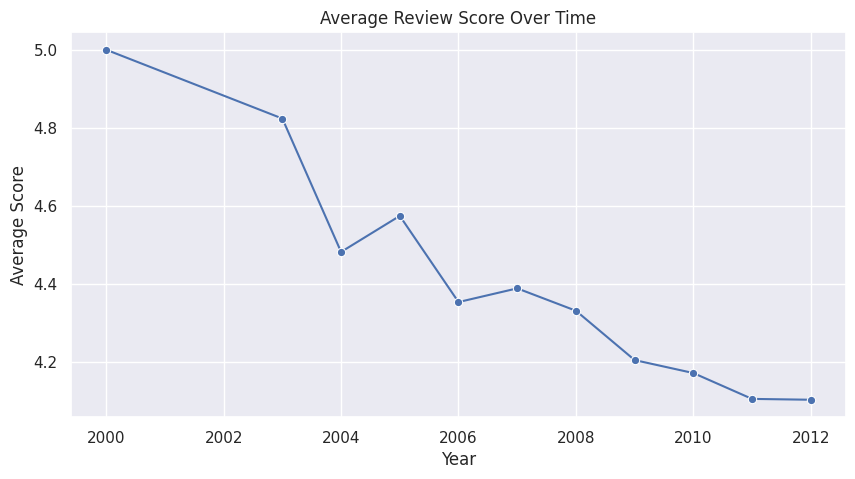


### Interpretation

This chart shows how average customer satisfaction changed over time.
If the average score drops, the company should investigate product quality or customer experience issues.
If it increases, it means customers are becoming more satisfied.


In [ ]:
# ============================================================
# TASK 2: EXPLORATORY DATA ANALYSIS & CUSTOMER INSIGHTS
# ============================================================

display(Markdown("## Task 2: Exploratory Data Analysis & Customer Insights"))

display(Markdown("""
In this task, we explore customer review behavior.
We analyze rating distribution, sentiment distribution, review trends over time,
product popularity, customer activity, correlations, and outliers.
This helps the marketing team understand customer behavior and product performance.
"""))

# ------------------------------------------------------------
# 2.1 Basic statistics
# ------------------------------------------------------------

print("Basic statistics:")
display(df.describe())

print("Dataset columns:")
display(df.columns)

# ------------------------------------------------------------
# 2.2 Score distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Score")
plt.title("Distribution of Product Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.show()

display(Markdown("""
### Interpretation

This chart shows how customers rate products.
If scores 4 and 5 are the most common, it means most customers are satisfied.
For marketing, positive reviews can be used as social proof in advertisements and product pages.
"""))

# ------------------------------------------------------------
# 2.3 Sentiment distribution based on Score
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="ScoreSentiment", order=["Positive", "Neutral", "Negative"])
plt.title("Sentiment Distribution Based on Review Score")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

display(Markdown("""
### Interpretation

This chart groups reviews into positive, neutral, and negative categories.
It helps the company quickly understand the general customer mood.
"""))

# ------------------------------------------------------------
# 2.4 Reviews over time
# ------------------------------------------------------------

reviews_by_year = df.groupby("ReviewYear")["Id"].count().reset_index()
reviews_by_year.columns = ["ReviewYear", "NumberOfReviews"]

plt.figure(figsize=(10, 5))
sns.lineplot(data=reviews_by_year, x="ReviewYear", y="NumberOfReviews", marker="o")
plt.title("Number of Reviews Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

display(Markdown("""
### Interpretation

This line chart shows how customer review activity changed over time.
An increase in reviews can mean higher product popularity, stronger customer engagement, or platform growth.
"""))

# ------------------------------------------------------------
# 2.5 Monthly review activity
# ------------------------------------------------------------

reviews_by_month = df.groupby("ReviewMonth")["Id"].count().reset_index()
reviews_by_month.columns = ["ReviewMonth", "NumberOfReviews"]

plt.figure(figsize=(10, 5))
sns.barplot(data=reviews_by_month, x="ReviewMonth", y="NumberOfReviews")
plt.title("Monthly Review Activity")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()

display(Markdown("""
### Interpretation

This chart shows seasonal patterns in review activity.
If some months have more reviews, marketers can plan stronger campaigns during those periods.
"""))

# ------------------------------------------------------------
# 2.6 Top 10 most reviewed products
# ------------------------------------------------------------

top_products = df["ProductId"].value_counts().head(10).reset_index()
top_products.columns = ["ProductId", "NumberOfReviews"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x="NumberOfReviews", y="ProductId")
plt.title("Top 10 Products by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Product ID")
plt.show()

display(Markdown("""
### Interpretation

These are the most reviewed products in the dataset.
Products with many reviews can be considered highly visible or popular.
Marketing teams can focus on these products for promotions or product improvement.
"""))

# ------------------------------------------------------------
# 2.7 Top 10 most active customers
# ------------------------------------------------------------

top_users = df["UserId"].value_counts().head(10).reset_index()
top_users.columns = ["UserId", "NumberOfReviews"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_users, x="NumberOfReviews", y="UserId")
plt.title("Top 10 Most Active Customers")
plt.xlabel("Number of Reviews")
plt.ylabel("User ID")
plt.show()

display(Markdown("""
### Interpretation

This chart shows the most active customers based on review count.
These customers can be useful for loyalty programs, beta testing, and customer advocacy campaigns.
"""))

# ------------------------------------------------------------
# 2.8 Correlation heatmap
# ------------------------------------------------------------

numeric_columns = [
    "HelpfulnessNumerator",
    "HelpfulnessDenominator",
    "Score",
    "ReviewLength",
    "HelpfulnessRatio",
    "ReviewYear",
    "ReviewMonth"
]

correlation_data = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_data, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

display(Markdown("""
### Interpretation

The correlation heatmap shows relationships between numeric variables.
It helps us see which variables move together.
For example, helpfulness numerator and denominator are usually connected because both measure review usefulness.
"""))

# ------------------------------------------------------------
# 2.9 Outlier analysis: review length
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="ReviewLength")
plt.title("Outliers in Review Length")
plt.xlabel("Review Length")
plt.show()

display(Markdown("""
### Interpretation

The boxplot shows that some reviews are much longer than others.
Long reviews can be important because they often contain detailed customer feedback.
Marketing teams can analyze these long reviews to understand customer needs and complaints.
"""))

# ------------------------------------------------------------
# 2.10 Average score by year
# ------------------------------------------------------------

avg_score_by_year = df.groupby("ReviewYear")["Score"].mean().reset_index()
avg_score_by_year.columns = ["ReviewYear", "AverageScore"]

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_score_by_year, x="ReviewYear", y="AverageScore", marker="o")
plt.title("Average Review Score Over Time")
plt.xlabel("Year")
plt.ylabel("Average Score")
plt.show()

display(Markdown("""
### Interpretation

This chart shows how average customer satisfaction changed over time.
If the average score drops, the company should investigate product quality or customer experience issues.
If it increases, it means customers are becoming more satisfied.
"""))

## Task 3: Customer Segmentation & Targeting Model


In this task, we use K-Means Clustering to divide customers into meaningful groups.
The goal is to help the marketing team understand different customer types and create better targeting strategies.


Customer-level dataset:


,UserId,TotalReviews,AverageScore,AverageReviewLength,AverageHelpfulnessRatio,PositiveReviewRate,NegativeReviewRate
0,#oc-R115TNMSPFT9I7,1,2.0,719.0,0.666667,0.0,1.0
1,#oc-R119LM8D59ZW8Y,1,1.0,1951.0,0.454545,0.0,1.0
2,#oc-R11DNU2NBKQ23Z,1,1.0,146.0,0.000000,0.0,1.0
3,#oc-R13EBF129DBX88,1,2.0,225.0,0.000000,0.0,1.0
4,#oc-R13X3YIJ6GLT0C,1,4.0,4003.0,0.571429,1.0,0.0


Customer dataset shape:
(70396, 7)



### Interpretation

We grouped the original review dataset by UserId.
Now each row represents one customer, not one review.
This helps us analyze customer behavior and divide customers into segments.



### Interpretation

We selected customer behavior features for clustering.
Scaling is important because K-Means works better when all variables are on a similar scale.


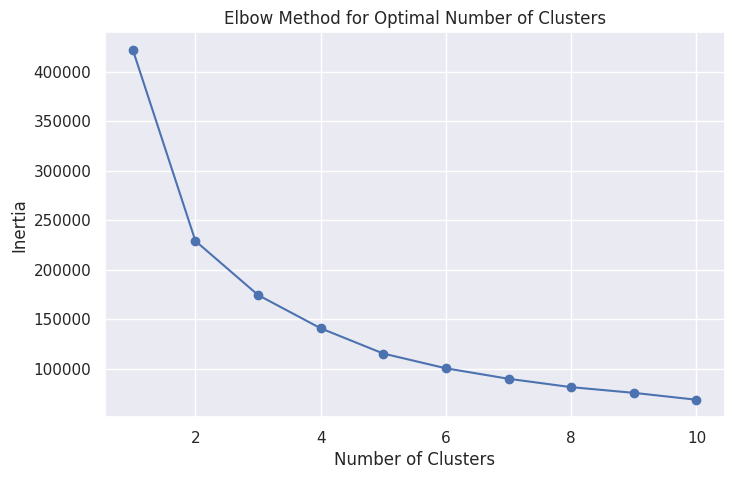


### Interpretation

The Elbow Method helps us choose the best number of clusters.
In this project, we use 4 clusters because it creates clear and simple customer segments for marketing decisions.


Customer data with segments:


,UserId,TotalReviews,AverageScore,AverageReviewLength,AverageHelpfulnessRatio,PositiveReviewRate,NegativeReviewRate,Segment
0,#oc-R115TNMSPFT9I7,1,2.0,719.0,0.666667,0.0,1.0,1
1,#oc-R119LM8D59ZW8Y,1,1.0,1951.0,0.454545,0.0,1.0,1
2,#oc-R11DNU2NBKQ23Z,1,1.0,146.0,0.000000,0.0,1.0,1
3,#oc-R13EBF129DBX88,1,2.0,225.0,0.000000,0.0,1.0,1
4,#oc-R13X3YIJ6GLT0C,1,4.0,4003.0,0.571429,1.0,0.0,0


Segment profile:


,Segment,TotalReviews,AverageScore,AverageReviewLength,AverageHelpfulnessRatio,PositiveReviewRate,NegativeReviewRate
0,0,1.267159,4.815487,455.528763,0.937213,0.989923,0.010077
1,1,1.276506,1.906535,452.235497,0.389001,0.028490,0.971510
2,2,9.269949,4.089486,722.949241,0.381725,0.745757,0.254243
3,3,1.306197,4.800425,322.378828,0.035654,0.987355,0.012645



### Interpretation

The segment profile shows the average behavior of customers in each cluster.
This helps us understand which segments are more positive, more active, or more critical.


Segment names:


,UserId,Segment,SegmentName
0,#oc-R115TNMSPFT9I7,1,Critical Customers
1,#oc-R119LM8D59ZW8Y,1,Critical Customers
2,#oc-R11DNU2NBKQ23Z,1,Critical Customers
3,#oc-R13EBF129DBX88,1,Critical Customers
4,#oc-R13X3YIJ6GLT0C,0,Low Engagement Customers


Segment summary:


,count
SegmentName,
Loyal Positive Reviewers,32563
Low Engagement Customers,22365
Critical Customers,15468


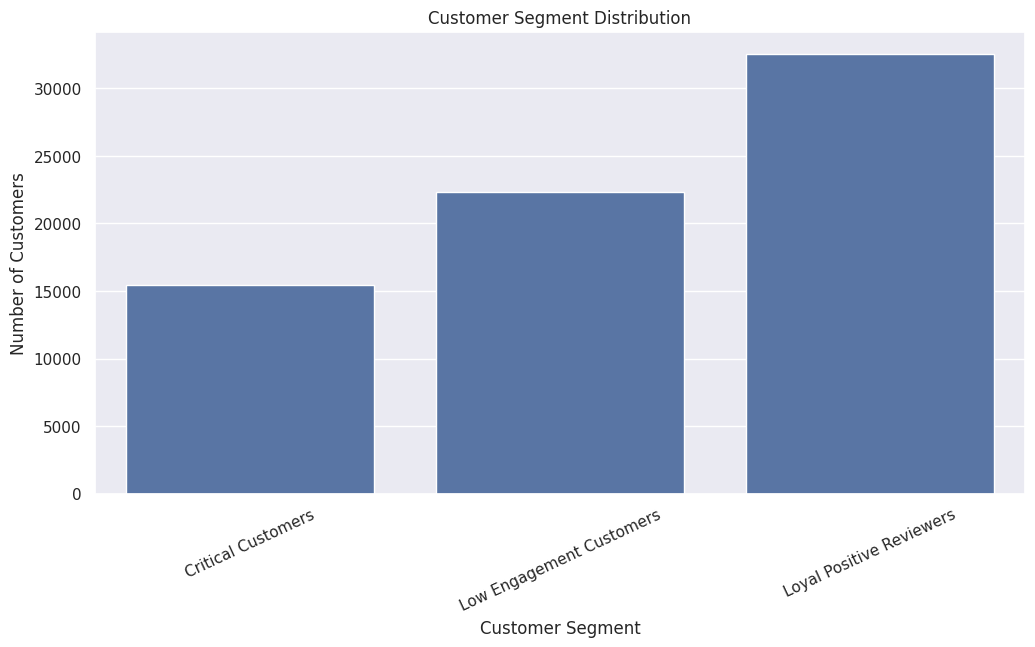


### Interpretation

This chart shows how many customers belong to each segment.
The company can use this information to understand which customer groups are the largest and most important.


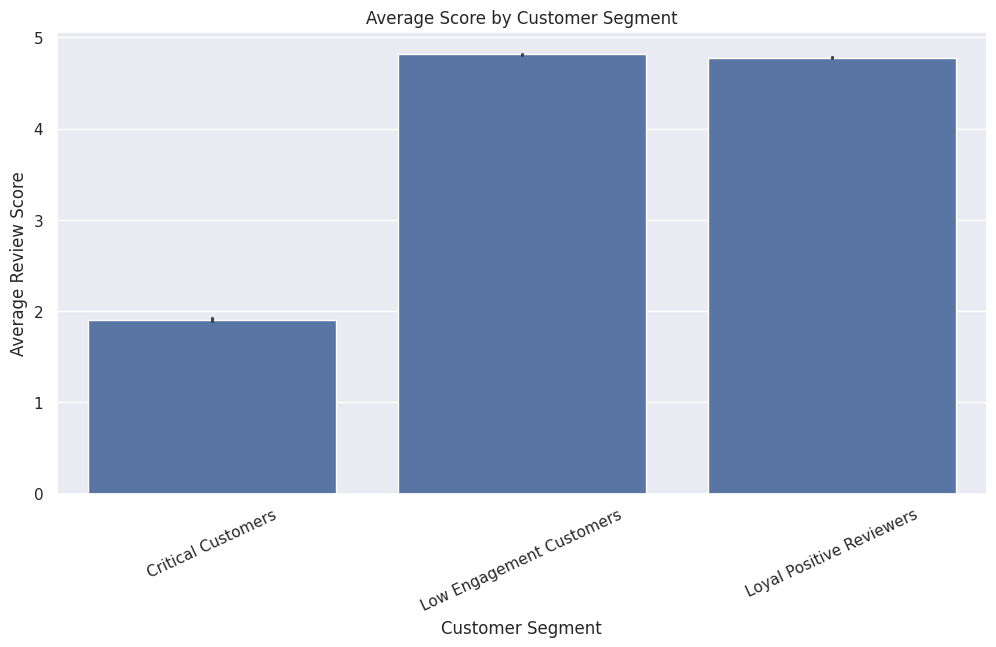


### Interpretation

This chart shows customer satisfaction by segment.
Segments with higher average scores are more satisfied.
Segments with lower average scores need more attention from the marketing and product teams.


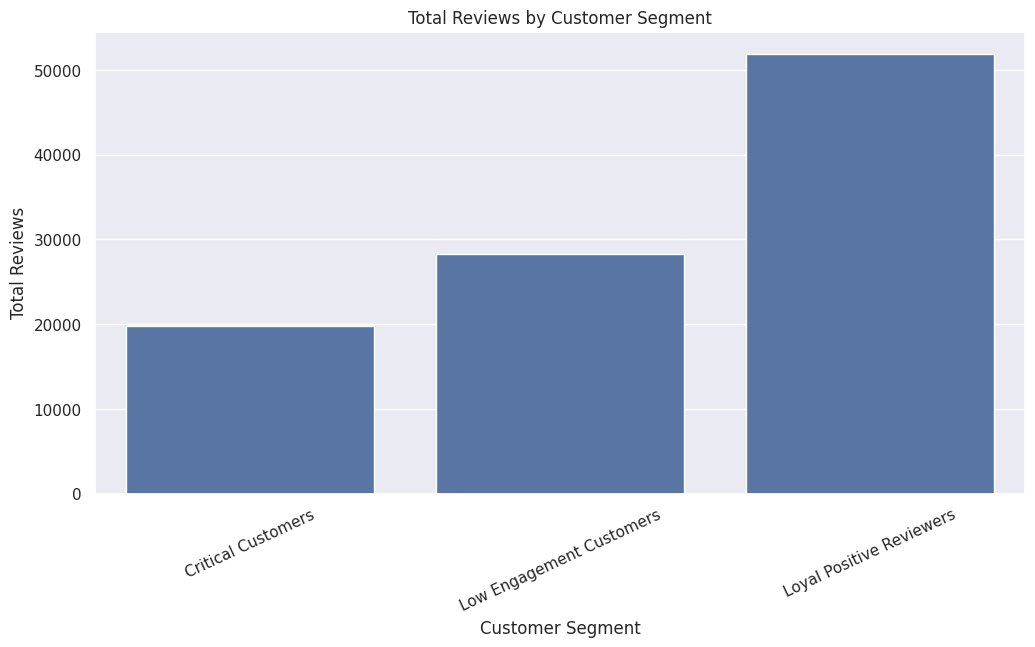


### Interpretation

This chart shows which customer segments create the most reviews.
Highly active segments can be useful for feedback collection, loyalty programs, and product promotion.


Marketing strategy by segment:


,SegmentName,MarketingStrategy
0,Loyal Positive Reviewers,"Use loyalty rewards, referral programs, and ea..."
1,Critical Customers,"Focus on customer support, product improvement..."
2,Low Engagement Customers,"Use simple offers, discounts, and reminder cam..."
3,Mixed Opinion Customers,Send personalized recommendations and ask for ...



### Final Interpretation for Task 3

K-Means clustering helped us divide customers into meaningful groups.
This is useful for marketing because different customers need different communication strategies.
Instead of sending the same message to everyone, the company can personalize campaigns for each segment.


In [ ]:
# ============================================================
# TASK 3: CUSTOMER SEGMENTATION & TARGETING MODEL
# ============================================================

display(Markdown("## Task 3: Customer Segmentation & Targeting Model"))

display(Markdown("""
In this task, we use K-Means Clustering to divide customers into meaningful groups.
The goal is to help the marketing team understand different customer types and create better targeting strategies.
"""))

# ------------------------------------------------------------
# 3.1 Create customer-level dataset
# ------------------------------------------------------------

customer_df = df.groupby("UserId").agg(
    TotalReviews=("Id", "count"),
    AverageScore=("Score", "mean"),
    AverageReviewLength=("ReviewLength", "mean"),
    AverageHelpfulnessRatio=("HelpfulnessRatio", "mean"),
    PositiveReviewRate=("PositiveReview", "mean")
).reset_index()

customer_df["NegativeReviewRate"] = 1 - customer_df["PositiveReviewRate"]

print("Customer-level dataset:")
display(customer_df.head())

print("Customer dataset shape:")
print(customer_df.shape)

display(Markdown("""
### Interpretation

We grouped the original review dataset by UserId.
Now each row represents one customer, not one review.
This helps us analyze customer behavior and divide customers into segments.
"""))

# ------------------------------------------------------------
# 3.2 Select features for clustering
# ------------------------------------------------------------

cluster_features = [
    "TotalReviews",
    "AverageScore",
    "AverageReviewLength",
    "AverageHelpfulnessRatio",
    "PositiveReviewRate",
    "NegativeReviewRate"
]

X_cluster = customer_df[cluster_features]

# Fill possible missing values
X_cluster = X_cluster.fillna(0)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

display(Markdown("""
### Interpretation

We selected customer behavior features for clustering.
Scaling is important because K-Means works better when all variables are on a similar scale.
"""))

# ------------------------------------------------------------
# 3.3 Elbow Method
# ------------------------------------------------------------

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

display(Markdown("""
### Interpretation

The Elbow Method helps us choose the best number of clusters.
In this project, we use 4 clusters because it creates clear and simple customer segments for marketing decisions.
"""))

# ------------------------------------------------------------
# 3.4 K-Means clustering model
# ------------------------------------------------------------

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df["Segment"] = kmeans.fit_predict(X_scaled)

print("Customer data with segments:")
display(customer_df.head())

# ------------------------------------------------------------
# 3.5 Segment profiling
# ------------------------------------------------------------

segment_profile = customer_df.groupby("Segment")[cluster_features].mean().reset_index()

print("Segment profile:")
display(segment_profile)

display(Markdown("""
### Interpretation

The segment profile shows the average behavior of customers in each cluster.
This helps us understand which segments are more positive, more active, or more critical.
"""))

# ------------------------------------------------------------
# 3.6 Assign business names to segments
# ------------------------------------------------------------

# Create segment names based on segment characteristics
segment_names = {}

for i in segment_profile["Segment"]:
    row = segment_profile[segment_profile["Segment"] == i].iloc[0]

    if row["AverageScore"] >= 4 and row["TotalReviews"] >= segment_profile["TotalReviews"].median():
        segment_names[i] = "Loyal Positive Reviewers"
    elif row["AverageScore"] < 3:
        segment_names[i] = "Critical Customers"
    elif row["TotalReviews"] < segment_profile["TotalReviews"].median():
        segment_names[i] = "Low Engagement Customers"
    else:
        segment_names[i] = "Mixed Opinion Customers"

customer_df["SegmentName"] = customer_df["Segment"].map(segment_names)

print("Segment names:")
display(customer_df[["UserId", "Segment", "SegmentName"]].head())

print("Segment summary:")
display(customer_df["SegmentName"].value_counts())

# ------------------------------------------------------------
# 3.7 Segment distribution chart
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
sns.countplot(data=customer_df, x="SegmentName")
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.show()

display(Markdown("""
### Interpretation

This chart shows how many customers belong to each segment.
The company can use this information to understand which customer groups are the largest and most important.
"""))

# ------------------------------------------------------------
# 3.8 Average score by segment
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
sns.barplot(data=customer_df, x="SegmentName", y="AverageScore")
plt.title("Average Score by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Review Score")
plt.xticks(rotation=25)
plt.show()

display(Markdown("""
### Interpretation

This chart shows customer satisfaction by segment.
Segments with higher average scores are more satisfied.
Segments with lower average scores need more attention from the marketing and product teams.
"""))

# ------------------------------------------------------------
# 3.9 Total reviews by segment
# ------------------------------------------------------------

segment_reviews = customer_df.groupby("SegmentName")["TotalReviews"].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=segment_reviews, x="SegmentName", y="TotalReviews")
plt.title("Total Reviews by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Reviews")
plt.xticks(rotation=25)
plt.show()

display(Markdown("""
### Interpretation

This chart shows which customer segments create the most reviews.
Highly active segments can be useful for feedback collection, loyalty programs, and product promotion.
"""))

# ------------------------------------------------------------
# 3.10 Marketing strategy for each segment
# ------------------------------------------------------------

strategy_data = {
    "SegmentName": [
        "Loyal Positive Reviewers",
        "Critical Customers",
        "Low Engagement Customers",
        "Mixed Opinion Customers"
    ],
    "MarketingStrategy": [
        "Use loyalty rewards, referral programs, and early access to new products.",
        "Focus on customer support, product improvement, and problem-solving messages.",
        "Use simple offers, discounts, and reminder campaigns to increase engagement.",
        "Send personalized recommendations and ask for feedback to understand their needs better."
    ]
}

strategy_df = pd.DataFrame(strategy_data)

print("Marketing strategy by segment:")
display(strategy_df)

display(Markdown("""
### Final Interpretation for Task 3

K-Means clustering helped us divide customers into meaningful groups.
This is useful for marketing because different customers need different communication strategies.
Instead of sending the same message to everyone, the company can personalize campaigns for each segment.
"""))

## Task 4: Predictive Customer Behavior Model


In this task, we build a predictive model that predicts whether a customer review will be positive or not.
Since this dataset does not include churn or campaign response, we use review positivity as the customer behavior target.

A positive review means the customer gave a score of 4 or 5.
This model helps the marketing team understand which factors are connected to customer satisfaction.


Model dataset:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,...,ReviewDay,ReviewLength,HelpfulnessRatio,ScoreSentiment,PositiveReview,TotalReviews,AverageScore,AverageReviewLength,AverageHelpfulnessRatio,Segment
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,...,27,263,1.0,Positive,1,1,5.0,263.0,1.0,0
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,...,7,190,0.0,Negative,0,1,1.0,190.0,0.0,1
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,...,18,509,1.0,Positive,1,1,4.0,509.0,1.0,0
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,...,13,219,1.0,Negative,0,1,2.0,219.0,1.0,1
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,...,21,140,0.0,Positive,1,1,5.0,140.0,0.0,3


Model dataset shape:
(100000, 23)


...

,PositiveReview
0,1
1,0
2,1
3,0
4,1



### Interpretation

The target variable is PositiveReview.
If the score is 4 or 5, the value is 1.
If the score is 1, 2, or 3, the value is 0.

The model will learn patterns from the selected features and predict whether a review is positive.


Training data size: (75000, 10)
Testing data size: (25000, 10)
Random Forest model trained successfully.
Accuracy Score:
0.9477



### Interpretation

Accuracy shows how often the model predicted correctly.
A higher accuracy means the model is better at predicting whether a review is positive or not.


Confusion Matrix:
[[ 4716  1020]
 [  288 18976]]


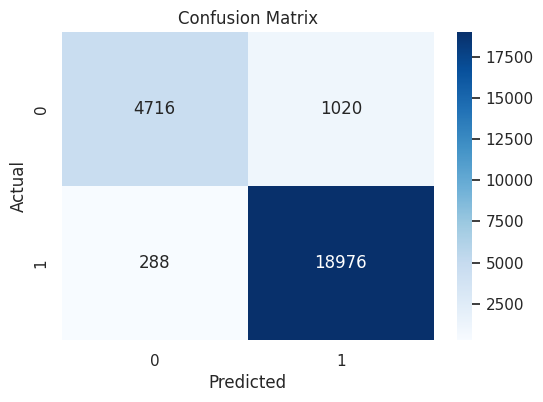


### Interpretation

The confusion matrix shows correct and incorrect predictions.

True Positive means the model correctly predicted a positive review.  
True Negative means the model correctly predicted a non-positive review.  
False Positive means the model predicted positive, but it was not positive.  
False Negative means the model predicted not positive, but it was actually positive.


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      5736
           1       0.95      0.99      0.97     19264

    accuracy                           0.95     25000
   macro avg       0.95      0.90      0.92     25000
weighted avg       0.95      0.95      0.95     25000




### Interpretation

The classification report shows precision, recall, and F1-score.
These metrics help us understand model quality in more detail than accuracy alone.


Feature Importance:


,Feature,Importance
9,Segment,0.680976
8,AverageHelpfulnessRatio,0.089118
2,HelpfulnessRatio,0.074105
6,TotalReviews,0.053102
1,HelpfulnessDenominator,0.040679
7,AverageReviewLength,0.018341
0,HelpfulnessNumerator,0.015481
3,ReviewLength,0.015151
4,ReviewYear,0.008559
5,ReviewMonth,0.004487


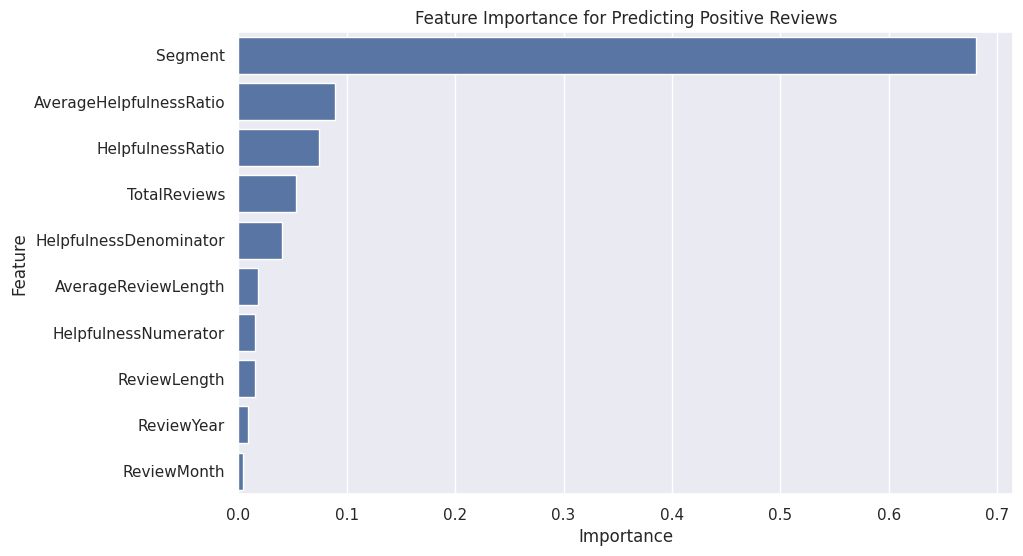


### Interpretation

The feature importance chart shows which variables were most useful for prediction.
For marketing, this helps understand what factors are connected to positive customer experience.
If review length, helpfulness, or customer history are important, the company can use these signals to monitor satisfaction.


Prediction columns added:


,Id,UserId,ProductId,Score,PositiveReview,PredictedPositiveReview,PredictedPositiveProbability
0,1,A3SGXH7AUHU8GW,B001E4KFG0,5,1,1,0.995489
1,2,A1D87F6ZCVE5NK,B00813GRG4,1,0,0,0.023677
2,3,ABXLMWJIXXAIN,B000LQOCH0,4,1,1,0.989940
3,4,A395BORC6FGVXV,B000UA0QIQ,2,0,0,0.020711
4,5,A1UQRSCLF8GW1T,B006K2ZZ7K,5,1,1,0.995200



### Final Interpretation for Task 4

The predictive model estimates whether a customer review will be positive.
This is useful for marketing because it helps identify customer satisfaction patterns.
The company can use this model to understand which customers or products are more likely to receive positive or negative feedback.


In [ ]:
# ============================================================
# TASK 4: PREDICTIVE CUSTOMER BEHAVIOR MODEL
# ============================================================

display(Markdown("## Task 4: Predictive Customer Behavior Model"))

display(Markdown("""
In this task, we build a predictive model that predicts whether a customer review will be positive or not.
Since this dataset does not include churn or campaign response, we use review positivity as the customer behavior target.

A positive review means the customer gave a score of 4 or 5.
This model helps the marketing team understand which factors are connected to customer satisfaction.
"""))

# ------------------------------------------------------------
# 4.1 Merge customer segment data with review-level data
# ------------------------------------------------------------

df_model = df.merge(
    customer_df[[
        "UserId",
        "TotalReviews",
        "AverageScore",
        "AverageReviewLength",
        "AverageHelpfulnessRatio",
        "Segment"
    ]],
    on="UserId",
    how="left"
)

print("Model dataset:")
display(df_model.head())

print("Model dataset shape:")
print(df_model.shape)

display(Markdown("""
### Interpretation

We merged the original review data with customer-level features.
Now the model can use both review information and customer behavior information.
"""))

# ------------------------------------------------------------
# 4.2 Select features and target
# ------------------------------------------------------------

model_features = [
    "HelpfulnessNumerator",
    "HelpfulnessDenominator",
    "HelpfulnessRatio",
    "ReviewLength",
    "ReviewYear",
    "ReviewMonth",
    "TotalReviews",
    "AverageReviewLength",
    "AverageHelpfulnessRatio",
    "Segment"
]

X = df_model[model_features]
y = df_model["PositiveReview"]

# Fill possible missing values
X = X.fillna(0)

print("Features used for prediction:")
display(X.head())

print("Target variable:")
display(y.head())

display(Markdown("""
### Interpretation

The target variable is PositiveReview.
If the score is 4 or 5, the value is 1.
If the score is 1, 2, or 3, the value is 0.

The model will learn patterns from the selected features and predict whether a review is positive.
"""))

# ------------------------------------------------------------
# 4.3 Train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

# ------------------------------------------------------------
# 4.4 Build Random Forest model
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

# ------------------------------------------------------------
# 4.5 Make predictions
# ------------------------------------------------------------

y_pred = rf_model.predict(X_test)

# ------------------------------------------------------------
# 4.6 Accuracy score
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:")
print(round(accuracy, 4))

display(Markdown("""
### Interpretation

Accuracy shows how often the model predicted correctly.
A higher accuracy means the model is better at predicting whether a review is positive or not.
"""))

# ------------------------------------------------------------
# 4.7 Confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

display(Markdown("""
### Interpretation

The confusion matrix shows correct and incorrect predictions.

True Positive means the model correctly predicted a positive review.
True Negative means the model correctly predicted a non-positive review.
False Positive means the model predicted positive, but it was not positive.
False Negative means the model predicted not positive, but it was actually positive.
"""))

# ------------------------------------------------------------
# 4.8 Classification report
# ------------------------------------------------------------

print("Classification Report:")
print(classification_report(y_test, y_pred))

display(Markdown("""
### Interpretation

The classification report shows precision, recall, and F1-score.
These metrics help us understand model quality in more detail than accuracy alone.
"""))

# ------------------------------------------------------------
# 4.9 Feature importance
# ------------------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": model_features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Feature Importance:")
display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance for Predicting Positive Reviews")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

display(Markdown("""
### Interpretation

The feature importance chart shows which variables were most useful for prediction.
For marketing, this helps understand what factors are connected to positive customer experience.
If review length, helpfulness, or customer history are important, the company can use these signals to monitor satisfaction.
"""))

# ------------------------------------------------------------
# 4.10 Save predictions for Power BI
# ------------------------------------------------------------

df_model["PredictedPositiveReview"] = rf_model.predict(X)
df_model["PredictedPositiveProbability"] = rf_model.predict_proba(X)[:, 1]

print("Prediction columns added:")
display(df_model[[
    "Id",
    "UserId",
    "ProductId",
    "Score",
    "PositiveReview",
    "PredictedPositiveReview",
    "PredictedPositiveProbability"
]].head())

display(Markdown("""
### Final Interpretation for Task 4

The predictive model estimates whether a customer review will be positive.
This is useful for marketing because it helps identify customer satisfaction patterns.
The company can use this model to understand which customers or products are more likely to receive positive or negative feedback.
"""))

## Task 5: AI Recommendation & Personalization System


In this task, we build a simple AI recommendation system.
The goal is to recommend products based on customer segments and product review performance.

This system helps the marketing team personalize offers instead of showing the same products to all customers.


Product performance table:


,ProductId,NumberOfReviews,AverageScore,AverageHelpfulnessRatio,AverageReviewLength,RecommendationScore
10530,B004ZWK338,6,5.0,1.0,382.666667,3.8
6278,B001VNEC68,6,5.0,1.0,644.833333,3.8
8337,B003P9XGE0,6,5.0,1.0,752.500000,3.8
8046,B003G52K5E,5,5.0,1.0,291.400000,3.8
2157,B000HQND56,7,5.0,1.0,322.571429,3.8
4876,B001EO5RBS,5,5.0,1.0,181.800000,3.8
8480,B003U2MDGO,5,5.0,1.0,235.200000,3.8
2224,B000I6O6RO,5,5.0,1.0,322.000000,3.8
3333,B000UCIBX6,5,5.0,1.0,594.800000,3.8
7742,B003752LCU,5,5.0,1.0,522.800000,3.8



### Interpretation

We created a product performance table.
Products are ranked using average rating and helpfulness ratio.
Products with higher scores are stronger candidates for recommendation.


...

Recommendations for: Low Engagement Customers


,SegmentName,ProductId,NumberOfReviews,AverageScore,AverageHelpfulnessRatio,AverageReviewLength,RecommendationScore
5572,Low Engagement Customers,B00008DFR5,3,5.0,1.0,1204.666667,3.8
5581,Low Engagement Customers,B0000CDBRJ,4,5.0,1.0,644.000000,3.8
5584,Low Engagement Customers,B0000CDBRY,5,5.0,1.0,332.400000,3.8
5585,Low Engagement Customers,B0000CDBRZ,5,5.0,1.0,332.400000,3.8
5587,Low Engagement Customers,B0000CEOKH,3,5.0,1.0,300.666667,3.8


Recommendations for: Loyal Positive Reviewers


,SegmentName,ProductId,NumberOfReviews,AverageScore,AverageHelpfulnessRatio,AverageReviewLength,RecommendationScore
16162,Loyal Positive Reviewers,B001G0NZRI,3,5.0,1.000000,294.666667,3.800000
19918,Loyal Positive Reviewers,B004X8TK9W,3,5.0,1.000000,470.333333,3.800000
12396,Loyal Positive Reviewers,B0001FQV5C,3,5.0,0.915459,4178.666667,3.774638
16026,Loyal Positive Reviewers,B001EQ5EJQ,9,5.0,0.833333,475.444444,3.750000
15540,Loyal Positive Reviewers,B001CEJ86K,5,5.0,0.800000,338.000000,3.740000



### Interpretation

The recommendation function takes a customer segment as input and returns the best products for that segment.
This is a simple version of personalization used in platforms like Amazon, Netflix, and Spotify.


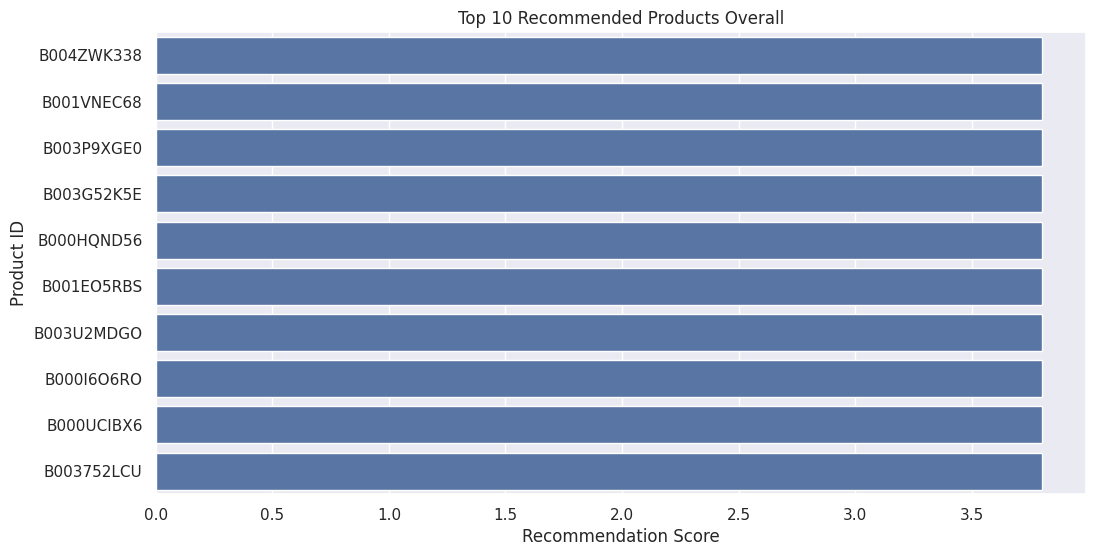


### Interpretation

This chart shows the top recommended products overall.
These products can be promoted to a wide audience because they have strong review performance.


Recommendation strategy by segment:


,SegmentName,RecommendationStrategy
0,Loyal Positive Reviewers,Recommend premium and highly rated products be...
1,Critical Customers,Recommend only stable high-rated products to r...
2,Low Engagement Customers,Recommend popular and simple products to incre...
3,Mixed Opinion Customers,Recommend personalized products based on previ...



### Final Interpretation for Task 5

The recommendation system helps the company personalize marketing offers.
Instead of recommending the same products to everyone, the company can recommend different products to different customer segments.
This can improve customer experience, increase click-through rate, and support higher customer engagement.


In [ ]:
# ============================================================
# TASK 5: AI RECOMMENDATION & PERSONALIZATION SYSTEM
# ============================================================

display(Markdown("## Task 5: AI Recommendation & Personalization System"))

display(Markdown("""
In this task, we build a simple AI recommendation system.
The goal is to recommend products based on customer segments and product review performance.

This system helps the marketing team personalize offers instead of showing the same products to all customers.
"""))

# ------------------------------------------------------------
# 5.1 Create product performance table
# ------------------------------------------------------------

product_df = df.groupby("ProductId").agg(
    NumberOfReviews=("Id", "count"),
    AverageScore=("Score", "mean"),
    AverageHelpfulnessRatio=("HelpfulnessRatio", "mean"),
    AverageReviewLength=("ReviewLength", "mean")
).reset_index()

# Keep products with enough reviews
product_df = product_df[product_df["NumberOfReviews"] >= 5]

# Create recommendation score
product_df["RecommendationScore"] = (
    product_df["AverageScore"] * 0.7 +
    product_df["AverageHelpfulnessRatio"] * 0.3
)

product_df = product_df.sort_values(by="RecommendationScore", ascending=False)

print("Product performance table:")
display(product_df.head(10))

display(Markdown("""
### Interpretation

We created a product performance table.
Products are ranked using average rating and helpfulness ratio.
Products with higher scores are stronger candidates for recommendation.
"""))

# ------------------------------------------------------------
# 5.2 Merge review data with customer segments
# ------------------------------------------------------------

review_with_segment = df.merge(
    customer_df[["UserId", "SegmentName"]],
    on="UserId",
    how="left"
)

print("Reviews with customer segment:")
display(review_with_segment.head())

display(Markdown("""
### Interpretation

We added customer segment information to the review dataset.
Now we can understand which products are popular inside each customer segment.
"""))

# ------------------------------------------------------------
# 5.3 Product recommendation by segment
# ------------------------------------------------------------

segment_product = review_with_segment.groupby(["SegmentName", "ProductId"]).agg(
    NumberOfReviews=("Id", "count"),
    AverageScore=("Score", "mean"),
    AverageHelpfulnessRatio=("HelpfulnessRatio", "mean"),
    AverageReviewLength=("ReviewLength", "mean")
).reset_index()

# Keep products with at least 3 reviews inside each segment
segment_product = segment_product[segment_product["NumberOfReviews"] >= 3]

# Segment-level recommendation score
segment_product["RecommendationScore"] = (
    segment_product["AverageScore"] * 0.7 +
    segment_product["AverageHelpfulnessRatio"] * 0.3
)

segment_product = segment_product.sort_values(
    by=["SegmentName", "RecommendationScore"],
    ascending=[True, False]
)

print("Segment-based product recommendations:")
display(segment_product.head(20))

display(Markdown("""
### Interpretation

This table shows recommended products for each customer segment.
A product gets a higher recommendation score when it has a high average rating and helpful reviews.
"""))

# ------------------------------------------------------------
# 5.4 Recommendation function
# ------------------------------------------------------------

def recommend_products_for_segment(segment_name, top_n=5):
    recommendations = segment_product[segment_product["SegmentName"] == segment_name]
    recommendations = recommendations.sort_values(by="RecommendationScore", ascending=False)
    return recommendations.head(top_n)

# Show recommendations for every segment
unique_segments = customer_df["SegmentName"].dropna().unique()

for segment in unique_segments:
    print("Recommendations for:", segment)
    display(recommend_products_for_segment(segment, 5))

display(Markdown("""
### Interpretation

The recommendation function takes a customer segment as input and returns the best products for that segment.
This is a simple version of personalization used in platforms like Amazon, Netflix, and Spotify.
"""))

# ------------------------------------------------------------
# 5.5 General top recommended products
# ------------------------------------------------------------

top_general_products = product_df.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_general_products,
    x="RecommendationScore",
    y="ProductId"
)
plt.title("Top 10 Recommended Products Overall")
plt.xlabel("Recommendation Score")
plt.ylabel("Product ID")
plt.show()

display(Markdown("""
### Interpretation

This chart shows the top recommended products overall.
These products can be promoted to a wide audience because they have strong review performance.
"""))

# ------------------------------------------------------------
# 5.6 Recommendation strategy by segment
# ------------------------------------------------------------

recommendation_strategy = pd.DataFrame({
    "SegmentName": [
        "Loyal Positive Reviewers",
        "Critical Customers",
        "Low Engagement Customers",
        "Mixed Opinion Customers"
    ],
    "RecommendationStrategy": [
        "Recommend premium and highly rated products because these customers already trust the brand.",
        "Recommend only stable high-rated products to reduce dissatisfaction and complaints.",
        "Recommend popular and simple products to increase engagement.",
        "Recommend personalized products based on previous reviews and ask for feedback."
    ]
})

print("Recommendation strategy by segment:")
display(recommendation_strategy)

display(Markdown("""
### Final Interpretation for Task 5

The recommendation system helps the company personalize marketing offers.
Instead of recommending the same products to everyone, the company can recommend different products to different customer segments.
This can improve customer experience, increase click-through rate, and support higher customer engagement.
"""))

## Task 6: Sentiment Analysis & Social Media Analytics


In this task, we use Natural Language Processing to analyze customer sentiment from review text.
We classify reviews as positive, neutral, or negative and analyze common words in customer reviews.

This helps the marketing team understand what customers like and what problems they mention.


Sentiment analysis sample:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,ReviewDate,ReviewYear,ReviewMonth,ReviewDay,ReviewLength,HelpfulnessRatio,ScoreSentiment,PositiveReview
75721,75722,B004MO6NI8,A1NOV41485TE0D,"S. Walker ""Wicked Walker Reviews""",1,1,5,1345593600,tastes good,This brand of energy drink tastes good and rea...,2012-08-22,2012,8,22,250,1.0,Positive,1
80184,80185,B000J2JKGO,A2TJG4N8LNJW23,Blythe Dresser,3,3,5,1316995200,Great choice for the active young dog!,I'm the owner of a year and a half old beagle ...,2011-09-26,2011,9,26,1047,1.0,Positive,1
19864,19865,B00390T5JA,A4HPRAH83XJMN,"L. T. Smith ""xlh_stud""",2,2,5,1321056000,Love my Keurig!,Great product! Perfect for coffee lovers becau...,2011-11-12,2011,11,12,776,1.0,Positive,1
76699,76700,B0049ULB78,A7S0SH4IKOVIV,"SadGirl ""Sadgirl""",0,0,5,1208822400,Coffee,It had a great variety and I am not much of a ...,2008-04-22,2008,4,22,137,0.0,Positive,1
92991,92992,B004YV80OE,A2YM3KILJ1G0YJ,Jason,1,2,3,1316736000,Target Audience: Velveeta Fanatics,"First of all, to call this a ""Chicken and Broc...",2011-09-23,2011,9,23,1540,0.5,Neutral,0


Sample size:
(20000, 18)



### Interpretation

We use a sample of reviews for sentiment analysis because text analysis can be slow on a very large dataset.
The sample is enough to understand general customer sentiment.


TextBlob sentiment results:


,Text,Polarity,TextBlobSentiment
75721,This brand of energy drink tastes good and rea...,0.366667,Positive
80184,I'm the owner of a year and a half old beagle ...,0.188043,Positive
19864,Great product! Perfect for coffee lovers becau...,0.439805,Positive
76699,It had a great variety and I am not much of a ...,0.381250,Positive
92991,"First of all, to call this a ""Chicken and Broc...",0.084848,Positive



### Interpretation

TextBlob gives each review a polarity score.
Positive polarity means the text sounds positive.
Negative polarity means the text sounds negative.
Neutral polarity means the text does not strongly show positive or negative emotion.


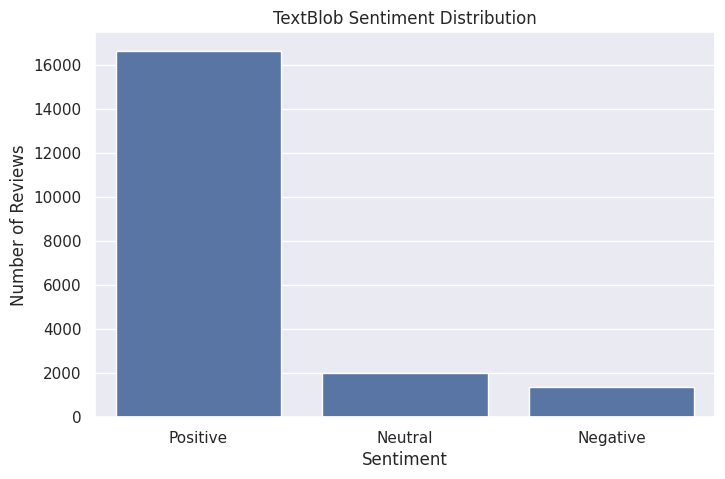


### Interpretation

This chart shows how many customer reviews are positive, neutral, and negative based on review text.
If positive reviews are the largest group, it means customers generally use positive language.
If negative reviews are high, the company should investigate customer complaints.


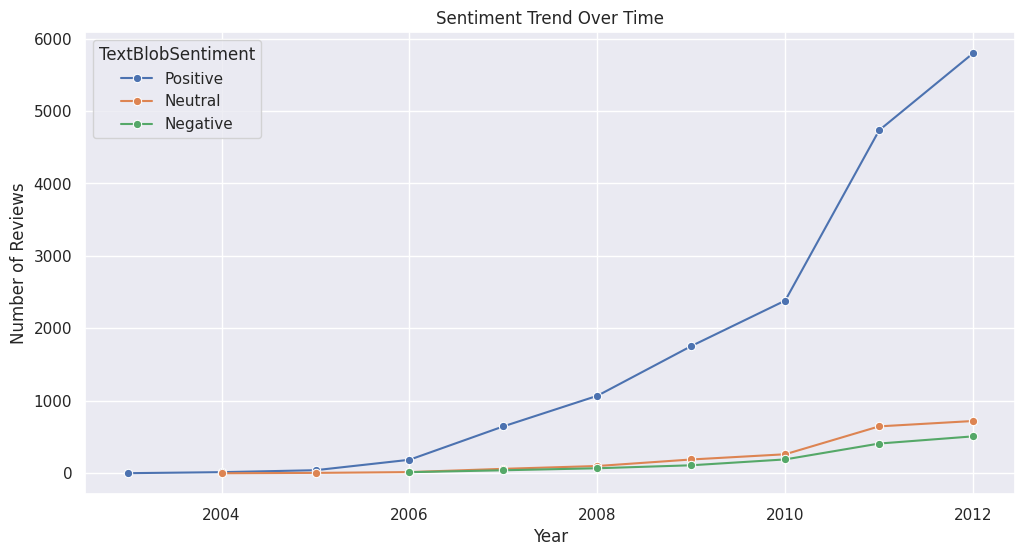


### Interpretation

This trend chart shows how customer sentiment changed over time.
Marketing teams can use it to identify periods when customers became more positive or more negative.


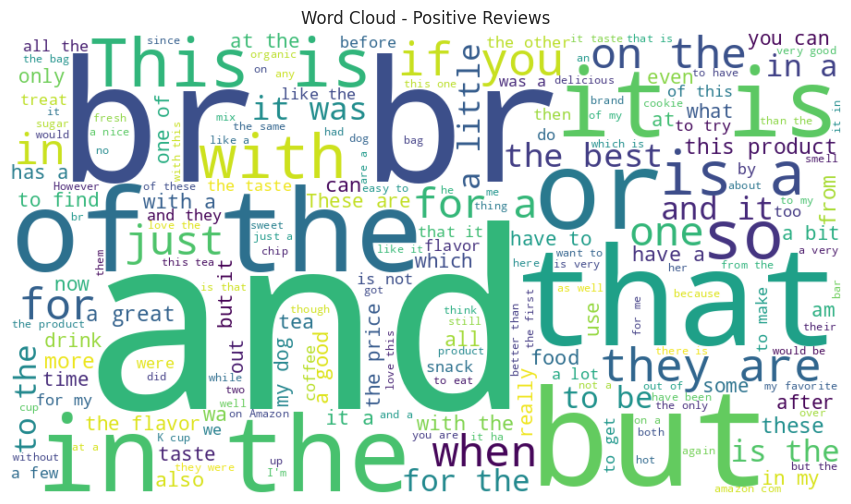


### Interpretation

The positive word cloud shows the most common words in positive reviews.
Marketing teams can use these words in advertising messages, product descriptions, and social media content.


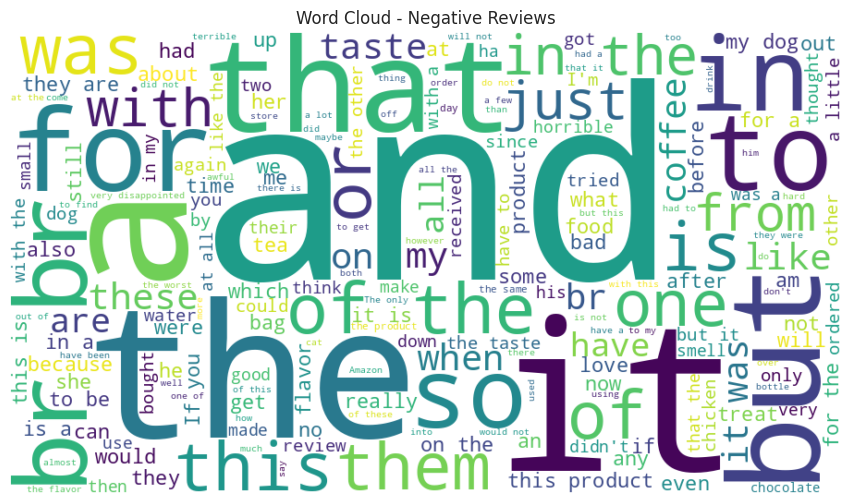


### Interpretation

The negative word cloud shows common words in negative reviews.
This helps the company understand customer pain points and improve product quality or communication.


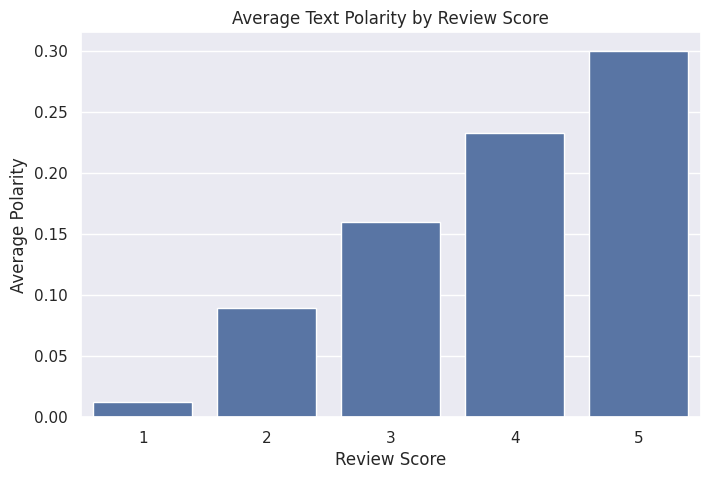


### Interpretation

This chart compares review score with text polarity.
Usually, higher scores have higher positive polarity.
This confirms that the text sentiment analysis is connected to customer ratings.


Sentiment summary:


,Sentiment,Share
0,Positive,83.185
1,Neutral,10.055
2,Negative,6.760



### Marketing Recommendation

The marketing team should use positive review themes in product pages, advertisements, and social media campaigns.
Positive customer language can become strong social proof.

Negative review themes should be used to improve product quality, customer service, and customer communication.
The company should monitor negative sentiment regularly to prevent customer dissatisfaction from growing.

Overall, sentiment analysis helps the company listen to customers and make better marketing decisions.



### Final Interpretation for Task 6

Sentiment analysis helped us understand the emotional tone of customer reviews.
Using NLP, we classified reviews as positive, neutral, or negative and visualized customer language through word clouds.
This gives the marketing team a clearer view of customer satisfaction and product perception.


In [ ]:
# ============================================================
# TASK 6: SENTIMENT ANALYSIS & SOCIAL MEDIA ANALYTICS
# ============================================================

display(Markdown("## Task 6: Sentiment Analysis & Social Media Analytics"))

display(Markdown("""
In this task, we use Natural Language Processing to analyze customer sentiment from review text.
We classify reviews as positive, neutral, or negative and analyze common words in customer reviews.

This helps the marketing team understand what customers like and what problems they mention.
"""))

# ------------------------------------------------------------
# 6.1 Create sample for sentiment analysis
# ------------------------------------------------------------

sentiment_df = df.sample(n=min(20000, len(df)), random_state=42).copy()

print("Sentiment analysis sample:")
display(sentiment_df.head())

print("Sample size:")
print(sentiment_df.shape)

display(Markdown("""
### Interpretation

We use a sample of reviews for sentiment analysis because text analysis can be slow on a very large dataset.
The sample is enough to understand general customer sentiment.
"""))

# ------------------------------------------------------------
# 6.2 TextBlob sentiment polarity
# ------------------------------------------------------------

def get_textblob_polarity(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

sentiment_df["Polarity"] = sentiment_df["Text"].apply(get_textblob_polarity)

def polarity_to_sentiment(polarity):
    if polarity > 0.05:
        return "Positive"
    elif polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

sentiment_df["TextBlobSentiment"] = sentiment_df["Polarity"].apply(polarity_to_sentiment)

print("TextBlob sentiment results:")
display(sentiment_df[["Text", "Polarity", "TextBlobSentiment"]].head())

display(Markdown("""
### Interpretation

TextBlob gives each review a polarity score.
Positive polarity means the text sounds positive.
Negative polarity means the text sounds negative.
Neutral polarity means the text does not strongly show positive or negative emotion.
"""))

# ------------------------------------------------------------
# 6.3 Sentiment distribution chart
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(
    data=sentiment_df,
    x="TextBlobSentiment",
    order=["Positive", "Neutral", "Negative"]
)
plt.title("TextBlob Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

display(Markdown("""
### Interpretation

This chart shows how many customer reviews are positive, neutral, and negative based on review text.
If positive reviews are the largest group, it means customers generally use positive language.
If negative reviews are high, the company should investigate customer complaints.
"""))

# ------------------------------------------------------------
# 6.4 Sentiment trend over time
# ------------------------------------------------------------

sentiment_trend = sentiment_df.groupby(["ReviewYear", "TextBlobSentiment"])["Id"].count().reset_index()
sentiment_trend.columns = ["ReviewYear", "TextBlobSentiment", "NumberOfReviews"]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=sentiment_trend,
    x="ReviewYear",
    y="NumberOfReviews",
    hue="TextBlobSentiment",
    marker="o"
)
plt.title("Sentiment Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

display(Markdown("""
### Interpretation

This trend chart shows how customer sentiment changed over time.
Marketing teams can use it to identify periods when customers became more positive or more negative.
"""))

# ------------------------------------------------------------
# 6.5 Word cloud for positive reviews
# ------------------------------------------------------------

positive_text = " ".join(
    sentiment_df[sentiment_df["TextBlobSentiment"] == "Positive"]["Text"].astype(str).head(5000)
)

if len(positive_text.strip()) > 0:
    wordcloud_positive = WordCloud(
        width=900,
        height=500,
        background_color="white",
        stopwords="english"
    ).generate(positive_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud_positive, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud - Positive Reviews")
    plt.show()
else:
    print("Not enough positive text for word cloud")

display(Markdown("""
### Interpretation

The positive word cloud shows the most common words in positive reviews.
Marketing teams can use these words in advertising messages, product descriptions, and social media content.
"""))

# ------------------------------------------------------------
# 6.6 Word cloud for negative reviews
# ------------------------------------------------------------

negative_text = " ".join(
    sentiment_df[sentiment_df["TextBlobSentiment"] == "Negative"]["Text"].astype(str).head(5000)
)

if len(negative_text.strip()) > 0:
    wordcloud_negative = WordCloud(
        width=900,
        height=500,
        background_color="white",
        stopwords="english"
    ).generate(negative_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud_negative, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud - Negative Reviews")
    plt.show()
else:
    print("Not enough negative text for word cloud")

display(Markdown("""
### Interpretation

The negative word cloud shows common words in negative reviews.
This helps the company understand customer pain points and improve product quality or communication.
"""))

# ------------------------------------------------------------
# 6.7 Average polarity by score
# ------------------------------------------------------------

polarity_by_score = sentiment_df.groupby("Score")["Polarity"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=polarity_by_score, x="Score", y="Polarity")
plt.title("Average Text Polarity by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Polarity")
plt.show()

display(Markdown("""
### Interpretation

This chart compares review score with text polarity.
Usually, higher scores have higher positive polarity.
This confirms that the text sentiment analysis is connected to customer ratings.
"""))

# ------------------------------------------------------------
# 6.8 Sentiment recommendation for marketing team
# ------------------------------------------------------------

sentiment_summary = sentiment_df["TextBlobSentiment"].value_counts(normalize=True).reset_index()
sentiment_summary.columns = ["Sentiment", "Share"]

sentiment_summary["Share"] = sentiment_summary["Share"] * 100

print("Sentiment summary:")
display(sentiment_summary)

display(Markdown("""
### Marketing Recommendation

The marketing team should use positive review themes in product pages, advertisements, and social media campaigns.
Positive customer language can become strong social proof.

Negative review themes should be used to improve product quality, customer service, and customer communication.
The company should monitor negative sentiment regularly to prevent customer dissatisfaction from growing.

Overall, sentiment analysis helps the company listen to customers and make better marketing decisions.
"""))

display(Markdown("""
### Final Interpretation for Task 6

Sentiment analysis helped us understand the emotional tone of customer reviews.
Using NLP, we classified reviews as positive, neutral, or negative and visualized customer language through word clouds.
This gives the marketing team a clearer view of customer satisfaction and product perception.
"""))

In [ ]:
# ============================================================
# FINAL BUSINESS INSIGHTS
# ============================================================

display(Markdown("## Final Business Insights"))

display(Markdown("""
### Key Finding 1: Most reviews are positive

The analysis shows that many customers give high review scores.
This means that customer satisfaction is generally strong.
The marketing team can use positive reviews as social proof in product pages, advertisements, and social media campaigns.

### Key Finding 2: Customers are not the same

Customer segmentation showed that users can be divided into different groups.
Some customers are loyal and positive, some are critical, and some have low engagement.
This means the company should not use the same marketing message for every customer.

### Key Finding 3: AI can predict customer satisfaction

The predictive model helped estimate whether a review will be positive or not.
This is useful because the company can identify patterns connected to customer satisfaction.
Marketing teams can use these signals to improve campaigns and customer experience.

### Key Finding 4: Recommendation system supports personalization

The recommendation system ranks products based on rating and helpfulness.
This helps the company recommend better products to different customer segments.
Personalized recommendations can improve customer engagement and increase the chance of purchase.

### Key Finding 5: Sentiment analysis shows customer emotions

Sentiment analysis helped us understand the emotional tone of customer reviews.
Positive words show what customers like.
Negative words show what problems customers mention.
This helps the company improve product quality and communication.

### Final Recommendation

The company should use AI-based segmentation, predictive modeling, recommendation systems, and sentiment analysis
to make better marketing decisions. This system can help personalize campaigns, improve customer satisfaction,
promote strong products, and react faster to negative customer feedback.
"""))

## Final Business Insights


### Key Finding 1: Most reviews are positive

The analysis shows that many customers give high review scores.
This means that customer satisfaction is generally strong.
The marketing team can use positive reviews as social proof in product pages, advertisements, and social media campaigns.

### Key Finding 2: Customers are not the same

Customer segmentation showed that users can be divided into different groups.
Some customers are loyal and positive, some are critical, and some have low engagement.
This means the company should not use the same marketing message for every customer.

### Key Finding 3: AI can predict customer satisfaction

The predictive model helped estimate whether a review will be positive or not.
This is useful because the company can identify patterns connected to customer satisfaction.
Marketing teams can use these signals to improve campaigns and customer experience.

### Key Finding 4: Recommendation system supports personalization

The recommendation system ranks products based on rating and helpfulness.
This helps the company recommend better products to different customer segments.
Personalized recommendations can improve customer engagement and increase the chance of purchase.

### Key Finding 5: Sentiment analysis shows customer emotions

Sentiment analysis helped us understand the emotional tone of customer reviews.
Positive words show what customers like.
Negative words show what problems customers mention.
This helps the company improve product quality and communication.

### Final Recommendation

The company should use AI-based segmentation, predictive modeling, recommendation systems, and sentiment analysis
to make better marketing decisions. This system can help personalize campaigns, improve customer satisfaction,
promote strong products, and react faster to negative customer feedback.


In [ ]:
# ============================================================
# EXPORT DATA FOR POWER BI
# ============================================================

display(Markdown("## Export Data for Power BI"))

# ------------------------------------------------------------
# 1. Review-level dataset for Power BI
# ------------------------------------------------------------

powerbi_reviews = df_model.copy()

# Add TextBlob sentiment results from sentiment sample
sentiment_export = sentiment_df[[
    "Id",
    "Polarity",
    "TextBlobSentiment"
]]

powerbi_reviews = powerbi_reviews.merge(sentiment_export, on="Id", how="left")

# Add customer segment names
powerbi_reviews = powerbi_reviews.merge(
    customer_df[["UserId", "SegmentName"]],
    on="UserId",
    how="left"
)

# ------------------------------------------------------------
# 2. Customer segments export
# ------------------------------------------------------------

customer_segments_export = customer_df.copy()

# ------------------------------------------------------------
# 3. Product recommendations export
# ------------------------------------------------------------

product_recommendations_export = segment_product.copy()

# ------------------------------------------------------------
# 4. Product performance export
# ------------------------------------------------------------

product_performance_export = product_df.copy()

# ------------------------------------------------------------
# 5. Sentiment sample export
# ------------------------------------------------------------

sentiment_sample_export = sentiment_df.copy()

# ------------------------------------------------------------
# 6. Segment strategy export
# ------------------------------------------------------------

segment_strategy_export = strategy_df.copy()

# ------------------------------------------------------------
# 7. Recommendation strategy export
# ------------------------------------------------------------

recommendation_strategy_export = recommendation_strategy.copy()

# ------------------------------------------------------------
# Save CSV files
# ------------------------------------------------------------

powerbi_reviews.to_csv("powerbi_reviews.csv", index=False)
customer_segments_export.to_csv("powerbi_customer_segments.csv", index=False)
product_recommendations_export.to_csv("powerbi_recommendations.csv", index=False)
product_performance_export.to_csv("powerbi_product_performance.csv", index=False)
sentiment_sample_export.to_csv("powerbi_sentiment_sample.csv", index=False)
segment_strategy_export.to_csv("powerbi_segment_strategy.csv", index=False)
recommendation_strategy_export.to_csv("powerbi_recommendation_strategy.csv", index=False)

print("Files exported successfully:")
print("1. powerbi_reviews.csv")
print("2. powerbi_customer_segments.csv")
print("3. powerbi_recommendations.csv")
print("4. powerbi_product_performance.csv")
print("5. powerbi_sentiment_sample.csv")
print("6. powerbi_segment_strategy.csv")
print("7. powerbi_recommendation_strategy.csv")

display(Markdown("""
### Interpretation

The cleaned and processed datasets were exported for Power BI.
These files will be used to create dashboard pages for executive overview, customer segmentation,
predictive analytics, recommendations, product performance, sentiment analysis, and marketing strategy.
"""))

## Export Data for Power BI

Files exported successfully:
1. powerbi_reviews.csv
2. powerbi_customer_segments.csv
3. powerbi_recommendations.csv
4. powerbi_product_performance.csv
5. powerbi_sentiment_sample.csv
6. powerbi_segment_strategy.csv
7. powerbi_recommendation_strategy.csv



### Interpretation

The cleaned and processed datasets were exported for Power BI.
These files will be used to create dashboard pages for executive overview, customer segmentation,
predictive analytics, recommendations, product performance, sentiment analysis, and marketing strategy.
